In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import torch
x = torch.tensor(3.0, requires_grad=True)
y = x**2 + 2*x
y.backward()
print(x.grad)

tensor(8.)


In [3]:
import torch
x = torch.tensor([2.0, 3.0])
w = torch.tensor([0.5, -1.0])
b = torch.tensor(1.0)
z = torch.dot(w, x) + b
out = torch.relu(z)
print("z =", z.item(), " out =", out.item())

z = -1.0  out = 0.0


In [4]:
import torch
x = torch.tensor([2.0, 3.0])
W = torch.tensor([[0.5, -1.0],     # neuron 1's weights
                  [1.0,  1.0]])     # neuron 2's weights
b = torch.tensor([1.0, -1.0])      # one bias per neuron
z = W @ x + b
out = torch.relu(z)
print("z   =", z)
print("out =", out)

z   = tensor([-1.,  4.])
out = tensor([0., 4.])


In [5]:
import torch
x  = torch.tensor([2.0, 3.0])

W1 = torch.tensor([[0.5, -1.0],
                   [1.0,  1.0]])
b1 = torch.tensor([1.0, -1.0])

W2 = torch.tensor([[2.0, 0.5]])     # one output neuron, takes 2 inputs from layer 1
b2 = torch.tensor([0.0])

h = torch.relu(W1 @ x + b1)         # hidden layer (you already know this part)
y = W2 @ h + b2                     # output layer, fed by h
print("hidden h =", h)
print("output y =", y)

hidden h = tensor([0., 4.])
output y = tensor([2.])


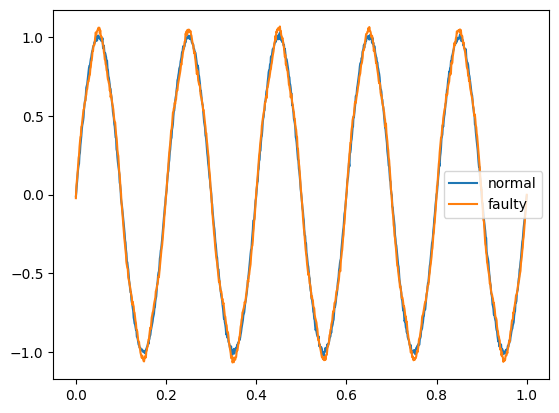

In [6]:
import torch, matplotlib.pyplot as plt
torch.manual_seed(0)

N = 1000
t = torch.linspace(0, 1, N)

def make_signal(faulty):
    base  = torch.sin(2 * 3.14159 * 5 * t)              # clean 5-cycle sine = "normal"
    noise = 0.01 * torch.randn(N)
    if faulty:
        base = base + 0.05 * torch.sin(2 * 3.14159 * 25 * t)  # harmonic = the fault
    return base + noise

normal = make_signal(False)
fault  = make_signal(True)

plt.plot(t, normal, label="normal")
plt.plot(t, fault,  label="faulty")
plt.legend(); plt.show()

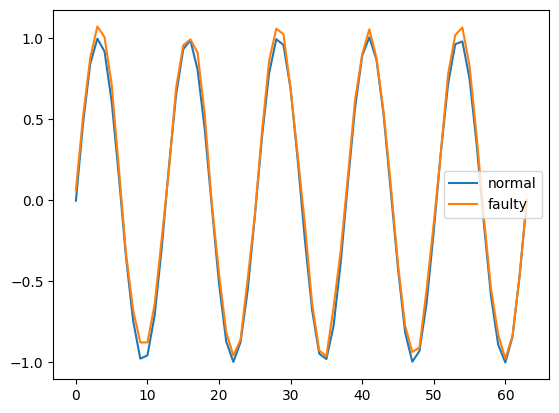

In [7]:
import torch, matplotlib.pyplot as plt
torch.manual_seed(0)

N = 64
t = torch.linspace(0, 1, N)

def make_signal(faulty):
    base = torch.sin(2*3.14159*5*t)
    if faulty:
        envelope = 0.1*torch.rand(N)        # random 0..1 per sample -> erratic, pulled toward 0
        base  = base + envelope
        noise = 0.02 * torch.randn(N)    # extra jitter
    else:
        noise = 0.005 * torch.randn(N)   # clean: light noise only
    return base + noise

# eyeball ONE of each before mass-producing
plt.plot(make_signal(False), label="normal")
plt.plot(make_signal(True),  label="faulty")
plt.legend(); plt.show()

In [8]:
M = 200
X = torch.stack([make_signal(False) for _ in range(M)] +
                [make_signal(True)  for _ in range(M)])
y = torch.cat([torch.zeros(M), torch.ones(M)])   # 0 = normal, 1 = faulty
print("X:", X.shape, "  y:", y.shape)

X: torch.Size([400, 64])   y: torch.Size([400])


In [9]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(64, 32),   # 64 inputs -> 8 hidden neurons  (the W@x+b you built by hand)
    nn.ReLU(),          # the gate
    nn.Linear(32, 1),    # 8 -> 1 output
    nn.Sigmoid()        # squish to 0..1 = "probability of fault"  (THIS is the 0-1 squisher, not ReLU)
)

loss_fn = nn.BCELoss()                              # measures how wrong the predictions are
opt = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(200):
    pred = model(X).squeeze()     # forward pass -> 400 predictions
    loss = loss_fn(pred, y)       # how wrong are we, as one number?
    opt.zero_grad()               # clear old gradients
    loss.backward()               # AUTOGRAD: gradient of loss w.r.t. every weight (your x.grad=8, at scale)
    opt.step()                    # nudge every weight a step downhill
    if epoch % 20 == 0:
        print(f"epoch {epoch:3d}   loss {loss.item():.4f}")


epoch   0   loss 0.6972
epoch  20   loss 0.5221
epoch  40   loss 0.1630
epoch  60   loss 0.0345
epoch  80   loss 0.0136
epoch 100   loss 0.0082
epoch 120   loss 0.0058
epoch 140   loss 0.0044
epoch 160   loss 0.0035
epoch 180   loss 0.0029


In [10]:

with torch.no_grad():                      # we're testing, not training -> no gradients needed
    probs = model(X).squeeze()             # probability of fault for each of the 400 signals
    pred_label = (probs >.7).float()    # blank: above what probability do we call it "fault"?
    accuracy = (pred_label == y).float().mean()
    print("accuracy:", accuracy.item())


accuracy: 1.0


In [11]:

for name, p in model.named_parameters():
    print(name, tuple(p.shape))

print("\n--- layer 1 weights (first neuron) ---")
print(model[0].weight[0])      # 64 weights for hidden neuron #1
print("layer 1 biases:", model[0].bias)
print("\n--- layer 2 (output neuron) ---")
print(model[2].weight)         # 8 weights -> the single output
print("output bias:", model[2].bias)

0.weight (32, 64)
0.bias (32,)
2.weight (1, 32)
2.bias (1,)

--- layer 1 weights (first neuron) ---
tensor([-0.0179,  0.0286,  0.0531,  0.0704,  0.0196,  0.0117, -0.1085, -0.0912,
         0.0093,  0.0275,  0.0058, -0.0025,  0.1096, -0.0519,  0.0962, -0.1106,
         0.0803, -0.0771,  0.0035,  0.0544,  0.0617, -0.0419, -0.1158,  0.1241,
        -0.0635, -0.0649,  0.1223, -0.0928,  0.0515, -0.0736, -0.1136, -0.0462,
        -0.0050,  0.0282,  0.0591,  0.0781, -0.0614,  0.0264,  0.0970,  0.0997,
        -0.0398, -0.0558, -0.1045,  0.0476,  0.0585, -0.0304, -0.0273,  0.0403,
         0.0590, -0.1183,  0.0268, -0.1042, -0.1164, -0.0802,  0.0778,  0.1125,
         0.0954,  0.0682, -0.0795,  0.0391,  0.0997, -0.0954, -0.0194, -0.0988],
       grad_fn=<SelectBackward0>)
layer 1 biases: Parameter containing:
tensor([ 0.0883,  0.0680,  0.0553, -0.0268, -0.0418,  0.1063, -0.0527, -0.0487,
         0.0404, -0.0824,  0.0080,  0.0351,  0.1706,  0.0513, -0.0771,  0.1945,
         0.0965, -0.0445, -

In [12]:
def to_c_array(name, tensor):
    flat = tensor.flatten().tolist()
    body = ", ".join(f"{v:.6f}f" for v in flat)
    return f"const float {name}[] = {{{body}}};\n"

print(to_c_array("W1", model[0].weight))   # 8*64 = 512 values  (neuron j, input i) -> index j*64+i
print(to_c_array("b1", model[0].bias))     # 8 values
print(to_c_array("W2", model[2].weight))   # 8 values
print(to_c_array("b2", model[2].bias))     # 1 value

const float W1[] = {-0.017878f, 0.028613f, 0.053112f, 0.070382f, 0.019584f, 0.011665f, -0.108529f, -0.091179f, 0.009300f, 0.027534f, 0.005758f, -0.002517f, 0.109593f, -0.051904f, 0.096213f, -0.110589f, 0.080274f, -0.077125f, 0.003473f, 0.054449f, 0.061681f, -0.041855f, -0.115820f, 0.124096f, -0.063508f, -0.064860f, 0.122298f, -0.092840f, 0.051536f, -0.073635f, -0.113630f, -0.046161f, -0.004958f, 0.028176f, 0.059148f, 0.078147f, -0.061419f, 0.026350f, 0.097025f, 0.099688f, -0.039753f, -0.055803f, -0.104543f, 0.047572f, 0.058491f, -0.030443f, -0.027252f, 0.040252f, 0.059034f, -0.118335f, 0.026804f, -0.104229f, -0.116407f, -0.080182f, 0.077788f, 0.112454f, 0.095423f, 0.068170f, -0.079539f, 0.039074f, 0.099674f, -0.095378f, -0.019417f, -0.098835f, 0.743130f, 0.538103f, 0.208580f, 0.236046f, 0.385389f, 0.373125f, 0.758952f, 0.520949f, 0.270284f, 0.200535f, 0.194558f, 0.275257f, 0.516804f, 0.589642f, 0.341710f, 0.366593f, 0.349563f, 0.340598f, 0.482010f, 0.624177f, 0.424898f, 0.346517f, 0.15

In [13]:
torch.manual_seed(123)
print(to_c_array("test_normal", make_signal(False)))
print(to_c_array("test_fault",  make_signal(True)))

const float test_normal[] = {0.001687f, 0.477365f, 0.838508f, 0.994264f, 0.913250f, 0.607108f, 0.147946f, -0.343913f, -0.745943f, -0.980890f, -0.959134f, -0.722919f, -0.293862f, 0.207617f, 0.645260f, 0.932218f, 0.991855f, 0.806840f, 0.433046f, -0.045250f, -0.513523f, -0.859516f, -0.993312f, -0.890881f, -0.560845f, -0.107439f, 0.393258f, 0.776084f, 0.979011f, 0.949558f, 0.677024f, 0.232569f, -0.253368f, -0.679269f, -0.958591f, -0.979549f, -0.783785f, -0.393121f, 0.097055f, 0.557872f, 0.894266f, 1.007460f, 0.869168f, 0.520575f, 0.050358f, -0.434332f, -0.810594f, -0.995162f, -0.926497f, -0.634692f, -0.205556f, 0.300400f, 0.709750f, 0.969187f, 0.980200f, 0.750491f, 0.353280f, -0.153035f, -0.605190f, -0.907647f, -1.000503f, -0.844030f, -0.477358f, 0.001119f};

const float test_fault[] = {0.024922f, 0.489446f, 0.862333f, 1.025343f, 0.889121f, 0.671465f, 0.230846f, -0.249451f, -0.763291f, -0.977076f, -0.896958f, -0.641712f, -0.224620f, 0.207812f, 0.674487f, 1.015043f, 1.039950f, 0.872794f, 0.

In [14]:
torch.manual_seed(999)     # NEW seed -> signals the model never trained on
M2 = 100
Xtest = torch.stack([make_signal(False) for _ in range(M2)] +
                    [make_signal(True)  for _ in range(M2)])
ytest = torch.cat([torch.zeros(M2), torch.ones(M2)])

with torch.no_grad():
    probs = model(Xtest).squeeze()
    pred  = (probs >.70).float()          # BLANK 1: the decision cutoff
    acc   = (pred == ytest).float().mean()  # BLANK 2: which reduction gives "fraction correct"?
print("UNSEEN accuracy:", acc.item())

UNSEEN accuracy: 1.0


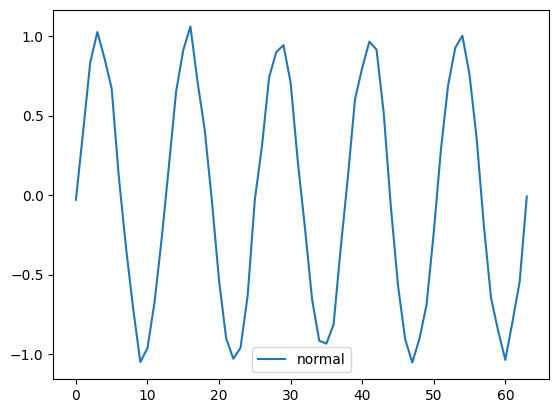

In [15]:
import torch
import matplotlib.pyplot as plt

t = torch.linspace(0, 1, 64)
normal = torch.sin(2 * torch.pi * 5 * t) + torch.randn(64) * 0.05
normal.shape

plt.plot(normal, label="normal")
plt.legend(); plt.show()

In [16]:
torch.randn(1000).min(), torch.randn(1000).max()

(tensor(-2.9403), tensor(3.1715))

In [17]:
make_signal(False).mean(), make_signal(True).mean()

(tensor(0.0002), tensor(0.0439))

In [18]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(64, 32),   # 64 inputs -> 8 hidden neurons  (the W@x+b you built by hand)
    nn.ReLU(),          # the gate
    nn.Linear(32, 1),    # 8 -> 1 output
    nn.Sigmoid()        # squish to 0..1 = "probability of fault"  (THIS is the 0-1 squisher, not ReLU)
)

In [19]:

def make_signal(faulty):
    base = torch.sin(2*3.14159*5*t)
    if faulty:
        base = base * torch.rand(N)        # blank 1: which RNG gives uniform [0,1)?
        noise= base * torch.randn(N)      # blank 2: heavier std for the fault
    else:
        noise = 0.2 * torch.randn(N)
    return base + noise

In [20]:
torch.manual_seed(0)
M = 200
Xtrain = torch.stack([make_signal(False) for _ in range(M)] + [make_signal(True) for _ in range(M)])
ytrain = torch.cat([torch.zeros(M), torch.ones(M)])


for epoch in range(500):
    pred = model(Xtrain).squeeze()     # forward pass -> 400 predictions
    loss = loss_fn(pred, ytrain)       # how wrong are we, as one number?
    opt.zero_grad()               # clear old gradients
    loss.backward()               # AUTOGRAD: gradient of loss w.r.t. every weight (your x.grad=8, at scale)
    opt.step()                    # nudge every weight a step downhill
    if epoch % 20 == 0:
        print(f"epoch {epoch:3d}   loss {loss.item():.4f}")


with torch.no_grad():
    probs = model(Xtrain).squeeze()
    pred  = (probs > 0.5).float()      # use 0.5 — the natural sigmoid cutoff, not 0.7
    train_acc = (pred == ytrain).float().mean()
    print("train accuracy:", train_acc.item())

epoch   0   loss 0.7083
epoch  20   loss 0.7083
epoch  40   loss 0.7083
epoch  60   loss 0.7083
epoch  80   loss 0.7083
epoch 100   loss 0.7083
epoch 120   loss 0.7083
epoch 140   loss 0.7083
epoch 160   loss 0.7083
epoch 180   loss 0.7083
epoch 200   loss 0.7083
epoch 220   loss 0.7083
epoch 240   loss 0.7083
epoch 260   loss 0.7083
epoch 280   loss 0.7083
epoch 300   loss 0.7083
epoch 320   loss 0.7083
epoch 340   loss 0.7083
epoch 360   loss 0.7083
epoch 380   loss 0.7083
epoch 400   loss 0.7083
epoch 420   loss 0.7083
epoch 440   loss 0.7083
epoch 460   loss 0.7083
epoch 480   loss 0.7083
train accuracy: 0.3499999940395355


In [21]:
torch.manual_seed(999)
M2 = 100
Xtest = torch.stack([make_signal(False) for _ in range(M2)] + [make_signal(True) for _ in range(M2)])
ytest = torch.cat([torch.zeros(M2), torch.ones(M2)])
with torch.no_grad():
    probs = model(Xtest).squeeze()
    pred  = (probs >.70).float()          # BLANK 1: the decision cutoff
    acc   = (pred == ytest).float().mean()  # BLANK 2: which reduction gives "fraction correct"?
print("UNSEEN accuracy:", acc.item())


UNSEEN accuracy: 0.5


In [22]:
make_signal(False).mean(), make_signal(True).mean()

(tensor(-0.0579), tensor(0.0378))

In [23]:
from torch import nn
model= nn.Sequential(
    nn.Linear(64,32),
    nn.ReLU(),
    nn.Linear(32,1),
    nn.Sigmoid()
)

total = sum([param.nelement() for param in model.parameters()])
print(f"Number of parameters in the model: {total}")

Number of parameters in the model: 2113


In [24]:
w1 = model[0].weight.data      # given — the weight tensor of layer 1
w1_max = w1.abs().max()      # biggest MAGNITUDE (ignore sign) in the tensor
scale1 = w1_max / 127       # map the biggest weight onto int8's ceiling
print(w1_max, scale1)

tensor(0.1250) tensor(0.0010)


In [25]:
import torch
q1 = torch.round(w1 / scale1)       # quantize → nearest integer in [-127, 127]
w1_hat = q1 * scale1                # dequantize → back to approximate float
err = (w1 - w1_hat).abs().max()    # worst-case reconstruction error over all weights
print(err)

tensor(0.0005)


In [26]:
import torch
torch.manual_seed(0)
N = 64
t = torch.linspace(0, 1, N)
def makesignal():
  base=torch.sin(2*torch.pi*5*t)
  noise=torch.rand(N)
  faulty=base+torch.sin(2*torch.pi*5*noise*t)
  return base,faulty
print(makesignal())

(tensor([ 0.0000e+00,  4.7825e-01,  8.4003e-01,  9.9720e-01,  9.1151e-01,
         6.0380e-01,  1.4904e-01, -3.4202e-01, -7.4978e-01, -9.7493e-01,
        -9.6262e-01, -7.1587e-01, -2.9475e-01,  1.9815e-01,  6.4279e-01,
         9.3087e-01,  9.9224e-01,  8.1194e-01,  4.3388e-01, -4.9846e-02,
        -5.2144e-01, -8.6603e-01, -9.9969e-01, -8.8987e-01, -5.6332e-01,
        -9.9567e-02,  3.8844e-01,  7.8183e-01,  9.8481e-01,  9.4793e-01,
         6.8017e-01,  2.4676e-01, -2.4676e-01, -6.8017e-01, -9.4793e-01,
        -9.8481e-01, -7.8183e-01, -3.8844e-01,  9.9566e-02,  5.6332e-01,
         8.8987e-01,  9.9969e-01,  8.6603e-01,  5.2144e-01,  4.9848e-02,
        -4.3388e-01, -8.1194e-01, -9.9224e-01, -9.3087e-01, -6.4279e-01,
        -1.9815e-01,  2.9475e-01,  7.1587e-01,  9.6262e-01,  9.7493e-01,
         7.4978e-01,  3.4202e-01, -1.4904e-01, -6.0380e-01, -9.1151e-01,
        -9.9720e-01, -8.4003e-01, -4.7825e-01, -5.5628e-07]), tensor([ 0.0000,  0.8520,  0.9282,  1.1934,  1.4870,  1.6038,

In [27]:
import torch
torch.manual_seed(0)
N = 64
t = torch.linspace(0, 1, N)
def makesignal(faulty):
  base=torch.sin(2*torch.pi*5*t)
  if faulty:
      base = base       # MULTIPLICATIVE collapse — mean stays ~0
      signal = base *(0.6 + torch.rand(1) * 0.4)   # heavy noise, randn (symmetric)
  else:
      signal = base + 0.05 * torch.randn(N)
  return signal
print(makesignal(False))

tensor([-0.0563,  0.4206,  0.8275,  0.9755,  0.9539,  0.6384,  0.1332, -0.4478,
        -0.7337, -1.0381, -0.9451, -0.7005, -0.2888,  0.2600,  0.6986,  0.9185,
         0.9246,  0.7271,  0.4622, -0.0102, -0.4915, -0.9438, -1.0168, -0.7972,
        -0.5258, -0.1288,  0.3798,  0.7910,  1.0543,  1.0272,  0.7275,  0.2046,
        -0.2774, -0.6786, -0.9726, -0.9724, -0.7598, -0.3828,  0.1316,  0.5854,
         0.8848,  1.0393,  0.8515,  0.5241,  0.0760, -0.3188, -0.8854, -1.0716,
        -0.9645, -0.5991, -0.1454,  0.3036,  0.7044,  0.9430,  1.0021,  0.7300,
         0.3197, -0.1118, -0.5278, -0.7410, -1.0738, -0.9017, -0.3873, -0.0276])


In [28]:
faultys = torch.stack([makesignal(True)  for _ in range(100)])
normals = torch.stack([makesignal(False) for _ in range(100)])
print(faultys.mean(), normals.mean())


tensor(7.5698e-08) tensor(-0.0003)


In [29]:
M = 500
Xtrain = torch.stack([makesignal(True) for _ in range(M)] + [makesignal(False) for _ in range(M)])
ytrain = torch.cat([torch.ones(M), torch.zeros(M)])
print(Xtrain.shape, ytrain.shape)

torch.Size([1000, 64]) torch.Size([1000])


In [30]:
torch.manual_seed(956789095)
N = 64
t = torch.linspace(0, 1, N)
k=100
Xtest = torch.stack([makesignal(True) for _ in range(k)] + [makesignal(False) for _ in range(k)])
ytest = torch.cat([torch.ones(k), torch.zeros(k)])
print(Xtest.shape, ytest.shape)

torch.Size([200, 64]) torch.Size([200])


In [31]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(500):
    pred = model(Xtrain).squeeze()
    loss = loss_fn(pred, ytrain)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(epoch, loss.item())

0 0.7335159182548523
50 0.6442357897758484
100 0.4308443069458008
150 0.29965659976005554
200 0.25121161341667175
250 0.2264728546142578
300 0.20465868711471558
350 0.19654521346092224
400 0.18342170119285583
450 0.1796441674232483


In [32]:
with torch.no_grad():
    w=[]
    train_pred = (model(Xtrain).squeeze() > 0.5).float()
    train_acc  = (train_pred == ytrain).float().mean()
    test_pred  = (model(Xtest).squeeze() > 0.5).float()
    test_acc   = (test_pred == ytest).float().mean()
    wrong = (test_pred != ytest)
    wrong.tolist()
    k=Xtest.abs().amax(dim=1)
    k.tolist()
    my_dict = dict(zip(wrong, k))
    print(my_dict)
print(train_acc.item(), test_acc.item())

{tensor(True): tensor(0.9949), tensor(True): tensor(0.9591), tensor(False): tensor(0.7262), tensor(False): tensor(0.7846), tensor(False): tensor(0.6976), tensor(False): tensor(0.8679), tensor(False): tensor(0.9358), tensor(False): tensor(0.7409), tensor(False): tensor(0.8239), tensor(False): tensor(0.8521), tensor(False): tensor(0.7829), tensor(False): tensor(0.7703), tensor(False): tensor(0.8973), tensor(False): tensor(0.6576), tensor(False): tensor(0.8621), tensor(False): tensor(0.9091), tensor(False): tensor(0.6896), tensor(False): tensor(0.8066), tensor(True): tensor(0.9692), tensor(False): tensor(0.6216), tensor(False): tensor(0.6558), tensor(False): tensor(0.7514), tensor(False): tensor(0.6930), tensor(False): tensor(0.6447), tensor(False): tensor(0.6271), tensor(True): tensor(0.9880), tensor(False): tensor(0.8405), tensor(False): tensor(0.9541), tensor(False): tensor(0.7609), tensor(False): tensor(0.7579), tensor(False): tensor(0.6786), tensor(False): tensor(0.7477), tensor(Fals

In [33]:
import copy
qmodel = copy.deepcopy(model)          # clone — so we keep the float model to compare against
with torch.no_grad():                  # editing weights directly, no gradient tracking
    for p in qmodel.parameters():
        scale = p.abs().max() / 127      # same rule as w1
        p.data = torch.round(p / scale) * scale

In [34]:
with torch.no_grad():
    qpred = (qmodel(Xtest).squeeze() > 0.5).float()
    qacc  = (qpred == ytest).float().mean()
print(qacc.item())


0.9300000071525574


In [35]:
W1 = model[0].weight.data      # layer 1 weights
b1 = model[0].bias.data        # layer 1 biases
W2 = model[2].weight.data      # layer 2 weights
b2 = model[2].bias.data        # layer 2 biases
print(W1.shape, b1.shape, W2.shape, b2.shape)

torch.Size([32, 64]) torch.Size([32]) torch.Size([1, 32]) torch.Size([1])


In [36]:
scale_w1 = W1.abs().max() / 127
W1_int8  = torch.round(W1 / scale_w1).to(torch.int8)

scale_w2 = W2.abs().max() / 127
W2_int8  = torch.round(W2 / scale_w2).to(torch.int8)

print(scale_w1.item(), scale_w2.item())
print(W1_int8.min().item(), W1_int8.max().item())

0.0024558203294873238 0.018442990258336067
-127 115


In [37]:
def to_c_array(name, tensor, ctype):
    vals = tensor.flatten().tolist()      # tensor -> flat Python list
    body = ", ".join(str(v) for v in vals)
    return f"{ctype} {name}[{len(vals)}] = {{{body}}};"

print(to_c_array("W1", W1_int8, "int8_t"))
print(to_c_array("b1", b1, "float"))     # biases stay float
print(to_c_array("W2", W2_int8, "int8_t"))
print(to_c_array("b2", b2, "float"))
print(f"const float scale_w1 = {scale_w1.item()}f;")
print(f"const float scale_w2 = {scale_w2.item()}f;")

int8_t W1[2048] = {18, -73, -48, -28, -43, -6, -75, 38, 4, 63, 40, 45, 70, 22, -41, -1, -25, -72, 11, -3, 47, 64, 52, 24, -14, 53, 11, -66, -17, -46, 21, -4, -12, 0, 74, -16, 48, -2, -59, -39, -6, -62, 21, -10, -32, 1, -5, -20, -14, 30, 68, 16, 9, -31, -24, -47, 25, 0, 47, -5, -7, 0, 29, 24, 73, -38, 81, 27, 42, 103, -10, -65, 7, -73, -33, -101, -56, -40, 62, 5, 18, 26, -18, -48, -39, -29, -96, -40, -7, -44, -13, 33, -20, -2, 33, 26, -73, -27, -65, -29, -59, -19, 51, -4, 8, 49, 38, 56, -1, -77, -38, -33, -31, 29, -65, 43, 9, 41, 4, 34, 59, -50, -8, 32, -78, -18, 45, 36, -19, 48, 43, 70, -19, 30, -27, -30, 6, -78, 28, -116, -57, -14, 114, 46, 80, 44, -7, -53, -4, -67, -103, -15, 22, -16, -51, -17, 32, -16, 14, -19, -127, -60, -65, -74, 1, 27, 29, 32, -27, 19, -37, -5, -10, -71, -32, -57, -51, -22, -36, -40, 61, -6, 42, 15, 96, -20, -69, -53, -20, -107, -26, 6, 37, -20, -24, -5, -40, -5, 25, 9, -29, 42, 19, 29, 30, 38, 1, 10, 36, -30, -12, 19, -14, -6, -43, 2, 49, -19, -19, 41, 2, -50, 3

In [38]:
print(make_signal(False).tolist())

[-0.009464538656175137, 0.5071308612823486, 0.621666431427002, 1.4116926193237305, 0.785490095615387, 0.39250433444976807, -0.015810638666152954, -0.6583870649337769, -1.1137309074401855, -0.9953532814979553, -0.8619337677955627, -0.9042221903800964, -0.24415293335914612, 0.1449909508228302, 0.612522304058075, 0.8054491281509399, 0.8034031391143799, 0.48276105523109436, 0.3746177852153778, -0.29259803891181946, -0.36529672145843506, -0.9051191806793213, -1.1369918584823608, -1.079228162765503, -0.8951102495193481, -0.4114788770675659, 0.4279841482639313, 0.3849707841873169, 1.0610432624816895, 1.0775855779647827, 0.705052375793457, 0.18652307987213135, 0.01177118718624115, -0.7022801637649536, -0.8700984716415405, -1.2687803506851196, -1.136000394821167, -0.5817016959190369, 0.28251731395721436, 0.9609871506690979, 1.2421778440475464, 0.9944288730621338, 1.1762516498565674, 0.3325381875038147, -0.10118304938077927, -0.7597156763076782, -0.41163691878318787, -1.0914982557296753, -1.0220

In [39]:
k=torch.rand((10000))
print(min(k),max(k))
print(k)

tensor(3.9220e-05) tensor(0.9999)
tensor([0.3312, 0.8286, 0.2640,  ..., 0.8214, 0.8595, 0.1804])


tensor(-0.6174) tensor(0.6174)


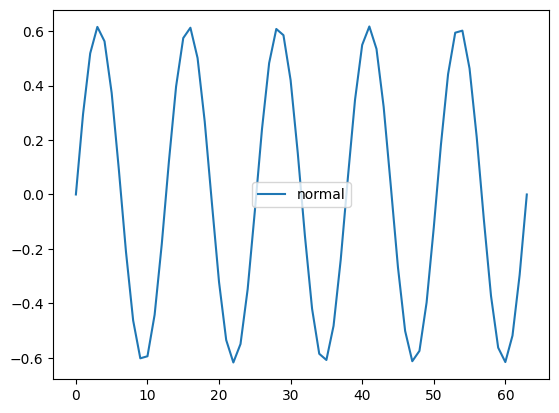

In [40]:
import torch
import matplotlib.pyplot as plt

t = torch.linspace(0, 1, 64)
normal = torch.sin(2 * torch.pi * 5 * t)*(0.6 + torch.rand(1) * 0.4)
# normal = 0.6 + torch.rand(64) * 0.4
normal.shape

print(min(normal),max(normal))

plt.plot(normal, label="normal")
plt.legend(); plt.show()

In [41]:
print(torch.rand(64),"\n",torch.rand(1))

tensor([0.9932, 0.2376, 0.0338, 0.3170, 0.1745, 0.8391, 0.5030, 0.7157, 0.1655,
        0.5300, 0.5512, 0.8328, 0.0528, 0.1436, 0.6866, 0.7483, 0.2592, 0.1372,
        0.0679, 0.4533, 0.9216, 0.5413, 0.1105, 0.4215, 0.6331, 0.3925, 0.9297,
        0.2814, 0.2810, 0.4192, 0.4706, 0.9928, 0.6073, 0.3995, 0.0451, 0.7733,
        0.3548, 0.9785, 0.5388, 0.7353, 0.0750, 0.2095, 0.5249, 0.6490, 0.7265,
        0.1051, 0.4090, 0.6232, 0.1617, 0.2860, 0.5436, 0.2430, 0.2157, 0.8035,
        0.2122, 0.3489, 0.8995, 0.6277, 0.0675, 0.5306, 0.6164, 0.3755, 0.4850,
        0.0611]) 
 tensor([0.0495])
